In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import squareform  
from skimage.measure import regionprops_table
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
import networkx as nx
from statsmodels.stats.multitest import multipletests

# ---- config (defined once, used throughout the notebook) ----
endo_genes = ["CDH5", "PECAM1", "VWF", "KDR", "FLT1", "PDGFB"]
fibro_genes = ["PDGFRB", "COL1A1", "COL1A2"]
genes = ['CDH5', 'MMP1', 'COL1A1', 'KDR', 'VWF', 'PECAM1', 'VEGFA', 'DLL4', 'ITGA6', 'SEMA3F', 'JAG1', 'FLT1', 'PDGFB', 'COL1A2', 'APLN', 'PDGFRB', 'ANGPT2', 'ICAM1']

# Gene-module settings (section 4).
module_lineage = "Endothelial"                      # population the modules are built from
module_marker_exclude = ["CDH5", "VWF", "PECAM1"]   # pan-endothelial markers: ON everywhere, so no module info
module_extra_exclude = ["COL1A1", "COL1A2", "PDGFRB"]         # collagen genes: fibroblast, not part of the endothelial modules
module_genes = [g for g in genes if g not in set(module_marker_exclude) | set(module_extra_exclude)]
min_on = 20                                         # a gene must be ON in >= this many cells to form an edge

all_data = pd.read_csv("clean_data_with_assigned_cell_type.csv")


## 1. Pairwise gene interactions

Which genes switch on together, and which are mutually exclusive? For every pair we
build a 2x2 on/off table, compute the odds ratio, and test it with **Fisher's exact
test** (Benjamini-Hochberg FDR).

- **Global (full population).** All 18 genes across **every** cell, including the all-0
  cells (split into lineages by the confident ratio) and the unknown-lineage cells.
  This asks which genes co-occur in the population as a whole. Note that the many
  both-off cells inflate positive odds ratios (the empty bottom-right corner of the
  2x2), so the global map is best read for *relative* structure, not absolute effect
  sizes.
- **Within lineage (confident cells only).** Splitting on `cell_type` and then testing
  two *marker* genes is circular - the markers helped define the lineage. Instead of
  leave-two-out, we restrict each lineage to its **confident** cells (>=2 of that
  lineage's markers and **none** of the other lineage's). Cross-lineage pairs (e.g.
  `COL1A1` inside endothelial) are then all-zero -> not testable, so the cross-lineage
  artefact cannot arise.
  - **Caveat (collider bias).** Selecting on ">=2 of a lineage's markers" makes *those
    markers* artificially anti-correlate within the subset (Berkson's paradox). So a
    pair where **both** genes are that lineage's defining markers is not interpretable -
    most visible for fibroblast, where "2 of 3" forces `COL1A1`/`COL1A2`/`PDGFRB` to
    look mutually exclusive. We therefore **flag and exclude defining-marker pairs** and
    read only the non-marker pairs (e.g. `APLN`-`ANGPT2`, `MMP1`-`DLL4` in endothelial),
    which carry no such bias.



In [47]:
# Pairwise gene co-occurrence via Fisher's exact test.
# log2 OR > 0 -> genes cooccur more than expected
# log2 OR < 0 -> genes are mutually exclusive

# added cutoffs for more biologically meaningful results:
# mask any pair where a gene is on in <min_pos cells and only trust a negative when n1n2/N > 1 (i.e. we don't just see no cooccurrent because both genes are rare)
def pairwise_cooccurrence(binary_df, genes, title="", ax=None,
                          min_pos=5, min_expected=1.0):
    """Pairwise gene co-occurrence via Fisher's exact test.

    min_pos       : a gene must be ON in >= this many cells for the pair to be shown
                    (otherwise the odds ratio is unstable).
    min_expected  : a NEGATIVE (mutually exclusive) call is only kept when the
                    expected overlap n1*n2/N >= this; below it there is no power
                    to detect depletion, so it is masked.
    """
    N = len(binary_df)
    present = {g: int((binary_df[g] == 1).sum()) for g in genes}
    rows = []
    for i, g1 in enumerate(genes):
        for g2 in genes[i + 1:]:
            a = int(((binary_df[g1] == 1) & (binary_df[g2] == 1)).sum())
            b = int(((binary_df[g1] == 1) & (binary_df[g2] == 0)).sum())
            c = int(((binary_df[g1] == 0) & (binary_df[g2] == 1)).sum())
            d = int(((binary_df[g1] == 0) & (binary_df[g2] == 0)).sum())
            odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
            _, p = fisher_exact([[a, b], [c, d]])
            expected = present[g1] * present[g2] / N   # overlap expected if independent
            rows.append(dict(gene1=g1, gene2=g2, both=a, odds_ratio=odds, pvalue=p,
                             n1=present[g1], n2=present[g2], expected=expected))
    res = pd.DataFrame(rows)
    res["FDR"] = multipletests(res.pvalue, method="fdr_bh")[1]
    res["log2_OR"] = np.log2(res.odds_ratio)

    # A pair is "testable" only if both genes clear the marginal cutoff.
    res["testable"] = (res.n1 >= min_pos) & (res.n2 >= min_pos)
    # Exclusivity (negative OR) additionally needs a detectable expected overlap.
    res["exclusivity_reliable"] = res.testable & (res.expected >= min_expected)

    M = pd.DataFrame(np.nan, index=genes, columns=genes)
    for _, r in res.iterrows():
        if not r.testable:
            continue                      # too few positives -> leave blank
        if r.log2_OR < 0 and not r.exclusivity_reliable:
            continue                      # can't trust a "mutually exclusive" call
        M.loc[r.gene1, r.gene2] = r.log2_OR
        M.loc[r.gene2, r.gene1] = r.log2_OR


    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))   # only make a figure if none passed
    lim = np.nanmax(np.abs(M.values)) if np.isfinite(M.values).any() else 1.0
    sns.heatmap(M, cmap="coolwarm", center=0, vmin=-lim, vmax=lim, square=True,
                mask=M.isna(), ax=ax, cbar_kws={"label": "log2 odds ratio"})
    ax.set_title(title)
    return res, M

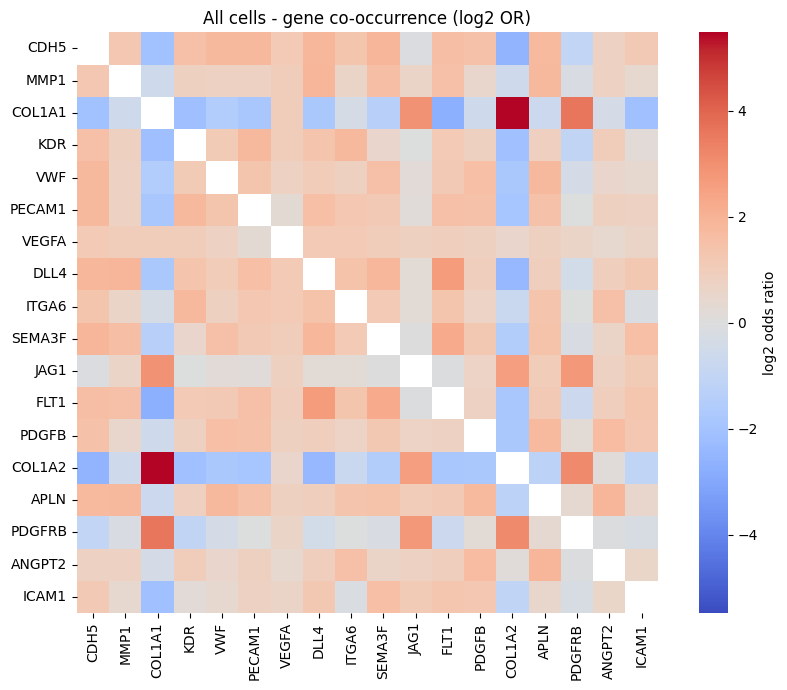

Significant pairs (FDR<0.05): 123  (co-occurring: 101, exclusive: 22)

Most significant co-occurring gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,608,509,278,23.719782,44.439079,5.473757,2.855165e-252
2,CDH5,KDR,4889,3548,1981,1329.514218,2.864849,1.518459,2.547955e-149
3,CDH5,VWF,4889,2269,1403,850.244577,3.387900,1.760391,1.122826e-146
4,CDH5,PECAM1,4889,1960,1225,734.455430,3.375395,1.755056,5.946295e-130
49,KDR,PECAM1,3548,1960,994,533.002223,3.437354,1.781298,1.206684e-127
6,CDH5,DLL4,4889,1393,913,521.987967,3.671052,1.876194,2.521302e-110
101,DLL4,FLT1,1393,721,278,76.979612,6.311400,2.657960,1.171710e-91
5,CDH5,VEGFA,4889,3845,1950,1440.806699,2.192632,1.132664,6.604292e-88
8,CDH5,SEMA3F,4889,922,619,345.493830,3.754721,1.908706,1.601486e-78
22,MMP1,DLL4,1178,1393,317,125.772515,3.695189,1.885648,1.482674e-60


Most significant mutually-exclusive gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
12,CDH5,COL1A2,4889,509,48,190.733579,0.167086,-2.581338,1.342468e-47
1,CDH5,COL1A1,4889,608,78,227.831072,0.234608,-2.091676,1.026105e-42
33,COL1A1,KDR,608,3548,48,165.339465,0.220978,-2.178025,1.859079e-33
57,KDR,COL1A2,3548,509,41,138.417414,0.228087,-2.132343,1.460748e-27
35,COL1A1,PECAM1,608,1960,30,91.337472,0.287018,-1.800788,4.920342e-15
70,VWF,COL1A2,2269,509,30,88.520043,0.292534,-1.773324,2.565429e-14
34,COL1A1,VWF,608,2269,42,105.737104,0.343956,-1.539702,5.261975e-14
82,PECAM1,COL1A2,1960,509,23,76.465088,0.264308,-1.919707,5.414428e-14
103,DLL4,COL1A2,1393,509,11,54.344830,0.186164,-2.425355,3.267477e-13
37,COL1A1,DLL4,608,1393,21,64.914846,0.295099,-1.760729,8.418605e-11


In [48]:
#  Full population (all cells, incl. all-0 and unknown lineage)
res_all, M_all = pairwise_cooccurrence(
    all_data, genes, title="All cells - gene co-occurrence (log2 OR)")
plt.tight_layout(); plt.show()

show_cols = {
    "gene1": "gene1", "gene2": "gene2",
    "n1": "# cells gene1 on", "n2": "# cells gene2 on",
    "both": "# overlap (both on)", "expected": "# overlap expected",
    "odds_ratio": "odds_ratio", "log2_OR": "log2_OR", "FDR": "FDR",
}
cols = list(show_cols)

sig = res_all[res_all.FDR < 0.05].copy()
sig.to_csv("all_cells_sig_pairs.csv")
print(f"Significant pairs (FDR<0.05): {len(sig)}  "
      f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
print("\nMost significant co-occurring gene pairs:")
display(sig[sig.log2_OR > 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
print("Most significant mutually-exclusive gene pairs:")
display(sig[sig.log2_OR < 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))

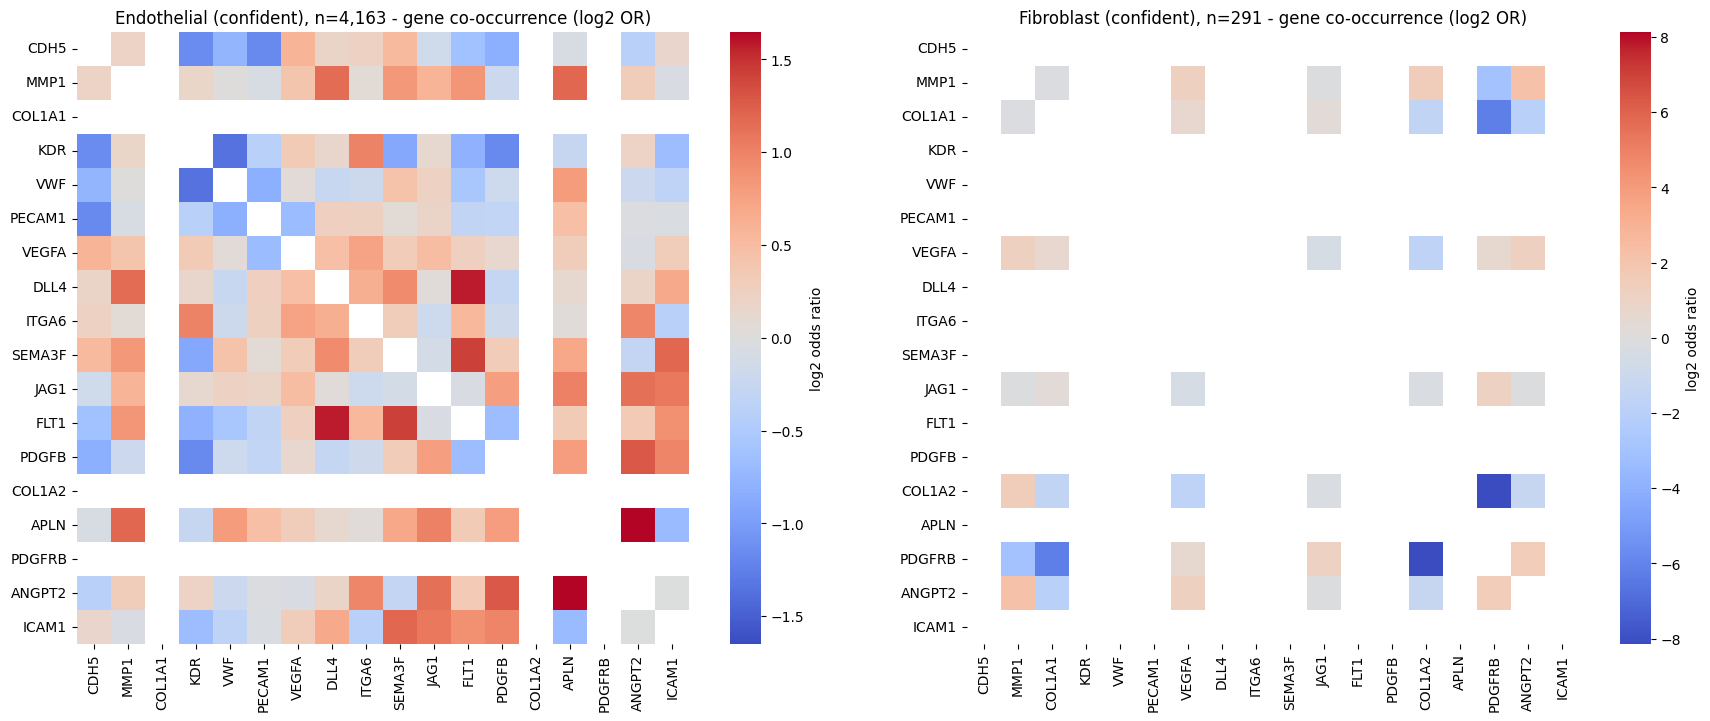

In [49]:
# Within-lineage co-occurrence WITHOUT circularity - use CONFIDENT cells only.
# A confident cell expresses >=2 of its lineage's markers and NONE of the other's, so
# the opposite lineage's markers are all-zero here and their pairs are simply not
# testable. The third panel uses ALL cells (incl. Unknown and Zero Reads) as the
# full-population reference.
subsets = {
    "endothelial": all_data[(all_data["cell_type"] == "Endothelial") & (all_data["confident"] == "Confident")],
    "fibroblast":  all_data[(all_data["cell_type"] == "Fibroblast") & (all_data["confident"] == "Confident")],
}
titles = {
    "endothelial": "Endothelial (confident)",
    "fibroblast":  "Fibroblast (confident)",
}
fig, axes = plt.subplots(1, len(subsets), figsize=(9 * len(subsets), 7))
lineage_res = {}
for ax, (key, sub) in zip(axes, subsets.items()):
    res, M = pairwise_cooccurrence(
        sub, genes, ax=ax,
        title=f"{titles[key]}, n={len(sub):,} - gene co-occurrence (log2 OR)")
    lineage_res[key] = res
plt.tight_layout(); plt.show()

In [50]:
# Significant within-lineage pairs (confident cells only).
# CAVEAT: a "confident" cell is selected on >=2 of its own markers, which makes those
# defining markers artificially anti-correlate within the subset (collider / Berkson
# bias). So pairs where BOTH genes areb that lineage's markers are NOT interpretable -
# we flag them and report the trustworthy (non-marker) pairs separately.
lineage_markers = {"endothelial": set(endo_genes), "fibroblast": set(fibro_genes)}

for lineage in ["endothelial", "fibroblast"]:
    res = lineage_res[lineage].copy()
    mk = lineage_markers[lineage]
    res["both_defining"] = res.gene1.isin(mk) & res.gene2.isin(mk)
    testable = res[res.testable]
    trust = testable[~testable.both_defining]          # interpretable pairs
    biased = testable[testable.both_defining]          # collider-biased, do not interpret
    sig = trust[trust.FDR < 0.05]
    print(f"{lineage}: {len(testable)} testable pairs "
          f"({len(trust)} interpretable, {len(biased)} defining-marker pairs excluded); "
          f"{len(sig)} interpretable & significant (FDR<0.05)  "
          f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
    print("  most significant co-occurring (non-marker pairs):")
    display(sig[sig.log2_OR > 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
    print("  most significant mutually-exclusive (non-marker pairs):")
    display(sig[sig.log2_OR < 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
    if len(biased):
        print("  defining-marker pairs (collider-biased, NOT interpreted):")
        display(biased[cols].rename(columns=show_cols))

endothelial: 105 testable pairs (90 interpretable, 15 defining-marker pairs excluded); 28 interpretable & significant (FDR<0.05)  (co-occurring: 25, exclusive: 3)
  most significant co-occurring (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
101,DLL4,FLT1,885,612,243,130.103291,2.984213,1.577350,7.203636e-28
118,SEMA3F,FLT1,550,612,154,80.855153,2.681724,1.423161,7.048073e-17
22,MMP1,DLL4,599,885,206,127.339659,2.228471,1.156054,1.264766e-14
99,DLL4,SEMA3F,885,550,175,116.922892,1.909963,0.933545,6.726080e-09
141,PDGFB,ANGPT2,690,262,81,43.425414,2.425677,1.278388,2.839330e-08
26,MMP1,FLT1,599,612,132,88.058612,1.819389,0.863454,1.809007e-06
5,CDH5,VEGFA,3306,1704,1418,1353.212587,1.498318,0.583344,3.503819e-06
24,MMP1,SEMA3F,599,550,118,79.137641,1.782490,0.833894,1.059802e-05
148,APLN,ANGPT2,160,262,26,10.069661,3.138670,1.650154,4.018940e-05
124,SEMA3F,ICAM1,550,182,45,24.045160,2.275777,1.186359,1.154112e-04


  most significant mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
75,PECAM1,VEGFA,1655,1704,564,677.424934,0.620568,-0.688338,4.236346e-12
53,KDR,SEMA3F,2565,550,266,338.878213,0.535479,-0.901099,1.877358e-10
61,KDR,ICAM1,2565,182,92,112.137881,0.623342,-0.681904,9.983903e-03


  defining-marker pairs (collider-biased, NOT interpreted):


...

,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR


  most significant mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR


  defining-marker pairs (collider-biased, NOT interpreted):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,280,260,249,250.171821,0.344375,-1.537946,1.000000e+00
45,COL1A1,PDGFRB,280,78,67,75.051546,0.013746,-6.184839,2.269806e-05
144,COL1A2,PDGFRB,260,78,47,69.690722,0.003531,-8.145517,1.461939e-18


### Conclusions - pairwise gene interactions

**Approach.** For every gene pair we build a 2x2 on/off table, take the odds ratio, and
test it with Fisher's exact test (Benjamini-Hochberg FDR). Positive log2 OR = co-occur
more than chance; negative = mutually exclusive.

**Assumptions / drawbacks.** Cells are treated as independent. In the all-cells map the many
all-negative cells inflate positive odds ratios! Within a cell type, pairs of that cell type's
own markers are collider-biased and excluded.


## 4. Gene Modules: Can we Extend from Multiple Pairwise Interactions into Modules?
- Restrict to endothelial cells and remove non-interesting genes (pan-endo markers CDH5, VWF and PECAM1, as well as fibroblast
markers COL1A1 and COL1A2) 
- **Node** = gene, **edge** = join two genes switched on together more than chance (positive co-occurrence, FDR<0.05 + requirement that each gene is ON in >=MIN_ON endothelial cells)
- **Edge weight** shows the strength of cooccurrence between the two genes, but how we define "strength" is open to interpretation....


#### Edge Weight Choices
- Possible candidates: log2 OR, -log10 FDR, Ochiai, phi/MCC
- OR is super inflated by double-negatives. Given we have really sparse data (most genes off), this isn't ideal
- -log 10 FDR depends on sample size, which scales with N and so over-weights the more abundant genes
- phi is good because it is a bounded effect size (between +-1), so edge widths are directly  comparable (when we use -log10FDR, it just splits out the abundant MMP1 into it's own module :( )


 phi / MCC  -> Pearson correlation of the two binary vectors, bounded [-1, 1].
Assumes: genes are symmetric 0/1 variables; uses all four 2x2 cells (incl. double-negatives)
but symmetrically, so it is NOT inflated by them the way the odds ratio is. It is an EFFECT
SIZE, independent of sample size. Caveat: when the two on-rates differ a lot, phi's maximum
attainable value is capped below 1, so rare x common pairs are intrinsically down-weighted.
-log10 FDR -> strength of EVIDENCE that the pair co-fires more than chance (not effect size).
Assumes: the Fisher/BH test is valid (independent cells, adequate counts -> we enforce n>=min_on)
and that all pairs share the same sample size N (true here: one cell population), so p-values
are comparable across edges. It scales with N, so on a raw (unfiltered) graph abundant genes
would get heavier edges; here it only re-weights the already-significant edge set, bounding that. 


In [57]:
# Build the phi-weighted, significant-positive edge set the module graph is made from.
# module_genes already excludes the pan-endothelial markers + collagen (see config cell).
B = all_data[(all_data["cell_type"] == module_lineage) & all_data["has_reads"]][module_genes].to_numpy()
on_count = B.sum(0)
on_freq = B.mean(0)

rows = []
for i in range(len(module_genes)):
    for j in range(i + 1, len(module_genes)):
        a = int(((B[:, i] == 1) & (B[:, j] == 1)).sum())      # both on
        b = int(on_count[i]) - a
        c = int(on_count[j]) - a
        d = len(B) - a - b - c
        _, p = fisher_exact([[a, b], [c, d]])
        odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
        denom = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
        phi = (a * d - b * c) / denom if denom else 0.0        # Matthews correlation of the two 0/1 vectors
        rows.append((module_genes[i], module_genes[j], np.log2(odds), phi, p,
                     int(on_count[i]), int(on_count[j])))
gp = pd.DataFrame(rows, columns=["g1", "g2", "log2_OR", "phi", "pvalue", "n1", "n2"])
gp["FDR"] = multipletests(gp.pvalue, method="fdr_bh")[1]

# Edges = significant positive co-occurrences with both genes ON in >= min_on cells; weight = phi.
pos = gp[(gp.log2_OR > 0) & (gp.FDR < 0.05) & (gp.n1 >= min_on) & (gp.n2 >= min_on)].copy()
print(f"{module_lineage}: {len(pos)} significant positive edges over {len(module_genes)} genes")


Endothelial: 35 significant positive edges over 12 genes


#### Choosing the Resolution
Higher resolution splits broad modules into smaller ones. 
- Resolution >= 2 -> some "modules" are just one gene, not that useful :(
- Resolution ~1.5 gives modules that have interpretable biological meaning 


In [58]:
Gp = nx.Graph()
Gp.add_nodes_from(module_genes)
for r in pos.itertuples():
    Gp.add_edge(r.g1, r.g2, weight=float(r.phi))

for gamma in [1.0, 1.5, 2.0, 2.5]:
    coms = list(nx.community.greedy_modularity_communities(Gp, weight="weight", resolution=gamma))
    Qv = nx.community.modularity(Gp, coms, weight="weight")
    print(f"resolution={gamma:>4}: {len(coms)} modules, Q={Qv:.3f}")
    for m, com in enumerate(coms):
        ordered = sorted(com, key=lambda g: -on_freq[module_genes.index(g)])
        print(f"    module {m}: {', '.join(ordered)}")

resolution= 1.0: 3 modules, Q=0.209
    module 0: PDGFB, ANGPT2, ICAM1, JAG1, APLN
    module 1: DLL4, MMP1, SEMA3F, FLT1
    module 2: KDR, VEGFA, ITGA6
resolution= 1.5: 4 modules, Q=0.193
    module 0: DLL4, MMP1, SEMA3F, FLT1
    module 1: KDR, VEGFA, ITGA6
    module 2: PDGFB, ANGPT2, APLN
    module 3: ICAM1, JAG1
resolution= 2.0: 6 modules, Q=0.096
    module 0: KDR, VEGFA, ITGA6
    module 1: PDGFB, ANGPT2, APLN
    module 2: ICAM1, JAG1
    module 3: DLL4, FLT1
    module 4: MMP1
    module 5: SEMA3F
resolution= 2.5: 7 modules, Q=0.047
    module 0: KDR, VEGFA, ITGA6
    module 1: PDGFB, ANGPT2, APLN
    module 2: ICAM1, JAG1
    module 3: MMP1
    module 4: DLL4
    module 5: SEMA3F
    module 6: FLT1


In [59]:
# METHOD ROBUSTNESS
# Are these groupings biological or just the result of our choice of edge weight/resolution?
from math import sqrt
from sklearn.metrics import adjusted_rand_score

Bc = all_data[(all_data["cell_type"] == module_lineage) & all_data["has_reads"]][module_genes].to_numpy()
Nc, onc = len(Bc), Bc.sum(0)
recs = []
for i in range(len(module_genes)):
    for j in range(i + 1, len(module_genes)):
        a = int(((Bc[:, i] == 1) & (Bc[:, j] == 1)).sum())
        n1, n2 = int(onc[i]), int(onc[j])
        b, c = n1 - a, n2 - a
        d = Nc - a - b - c
        _, p = fisher_exact([[a, b], [c, d]])
        odds = ((a + .5) * (d + .5)) / ((b + .5) * (c + .5))
        denom = sqrt((a + b) * (c + d) * (a + c) * (b + d))
        recs.append((module_genes[i], module_genes[j], a, n1, n2, np.log2(odds),
                     (a * d - b * c) / denom if denom else 0.0,           # phi / MCC
                     a / sqrt(n1 * n2) if n1 and n2 else 0.0, p))         # Ochiai
cmp = pd.DataFrame(recs, columns=["g1", "g2", "both", "n1", "n2", "log2_OR", "phi", "ochiai", "pvalue"])
cmp["FDR"] = multipletests(cmp.pvalue, method="fdr_bh")[1]
cmp["neglog_fdr"] = -np.log10(cmp.FDR.clip(lower=1e-300))

# One shared edge set (significant positive pairs); only the edge WEIGHT differs between runs.
E = cmp[(cmp.log2_OR > 0) & (cmp.FDR < 0.05) & (cmp.n1 >= min_on) & (cmp.n2 >= min_on)]

def modules_at(weight_col, gamma=1.5):
    G = nx.Graph(); G.add_nodes_from(module_genes)
    for r in E.itertuples():
        G.add_edge(r.g1, r.g2, weight=float(getattr(r, weight_col)))
    coms = list(nx.community.greedy_modularity_communities(G, weight="weight", resolution=gamma))
    return coms, nx.community.modularity(G, coms, weight="weight")

def as_labels(coms):
    lab, nxt = {}, 0
    for m, com in enumerate(coms):
        for g in com:
            lab[g] = m
        nxt = m + 1
    for g in module_genes:                     # isolated genes -> their own singleton
        if g not in lab:
            lab[g] = nxt; nxt += 1
    return [lab[g] for g in module_genes]

def fmt(com):
    return ", ".join(sorted(com, key=lambda g: -onc[module_genes.index(g)]))

gammas = [ 1.5]
weights = [("phi", "phi"), ("log2_OR", "log2 OR"), ("ochiai", "Ochiai"), ("neglog_fdr", "-log10 FDR")]

summary = []
for g in gammas:
    ref_g = as_labels(modules_at("phi", g)[0])
    print(f"================ gamma = {g} ================")
    row = {"gamma": g}
    for wc, name in weights:
        coms, Qv = modules_at(wc, g)
        ari = adjusted_rand_score(ref_g, as_labels(coms))
        row[f"{name} (k)"] = len(coms)
        row[f"{name} ARI"] = round(ari, 2)
        print(f"  [{name:11}] {len(coms)} modules")
        for c in sorted(coms, key=len, reverse=True):
            print(f"       - {fmt(c)}")





================ gamma = 1.5 ================
  [phi        ] 4 modules
       - DLL4, MMP1, SEMA3F, FLT1
       - KDR, VEGFA, ITGA6
       - PDGFB, ANGPT2, APLN
       - ICAM1, JAG1
  [log2 OR    ] 4 modules
       - DLL4, MMP1, SEMA3F, FLT1
       - KDR, VEGFA, ITGA6
       - PDGFB, ANGPT2, APLN
       - ICAM1, JAG1
  [Ochiai     ] 4 modules
       - DLL4, SEMA3F, FLT1, ICAM1
       - PDGFB, ANGPT2, JAG1, APLN
       - KDR, VEGFA, ITGA6
       - MMP1
  [-log10 FDR ] 4 modules
       - PDGFB, ANGPT2, ICAM1, JAG1, APLN
       - KDR, VEGFA, ITGA6
       - DLL4, SEMA3F, FLT1
       - MMP1


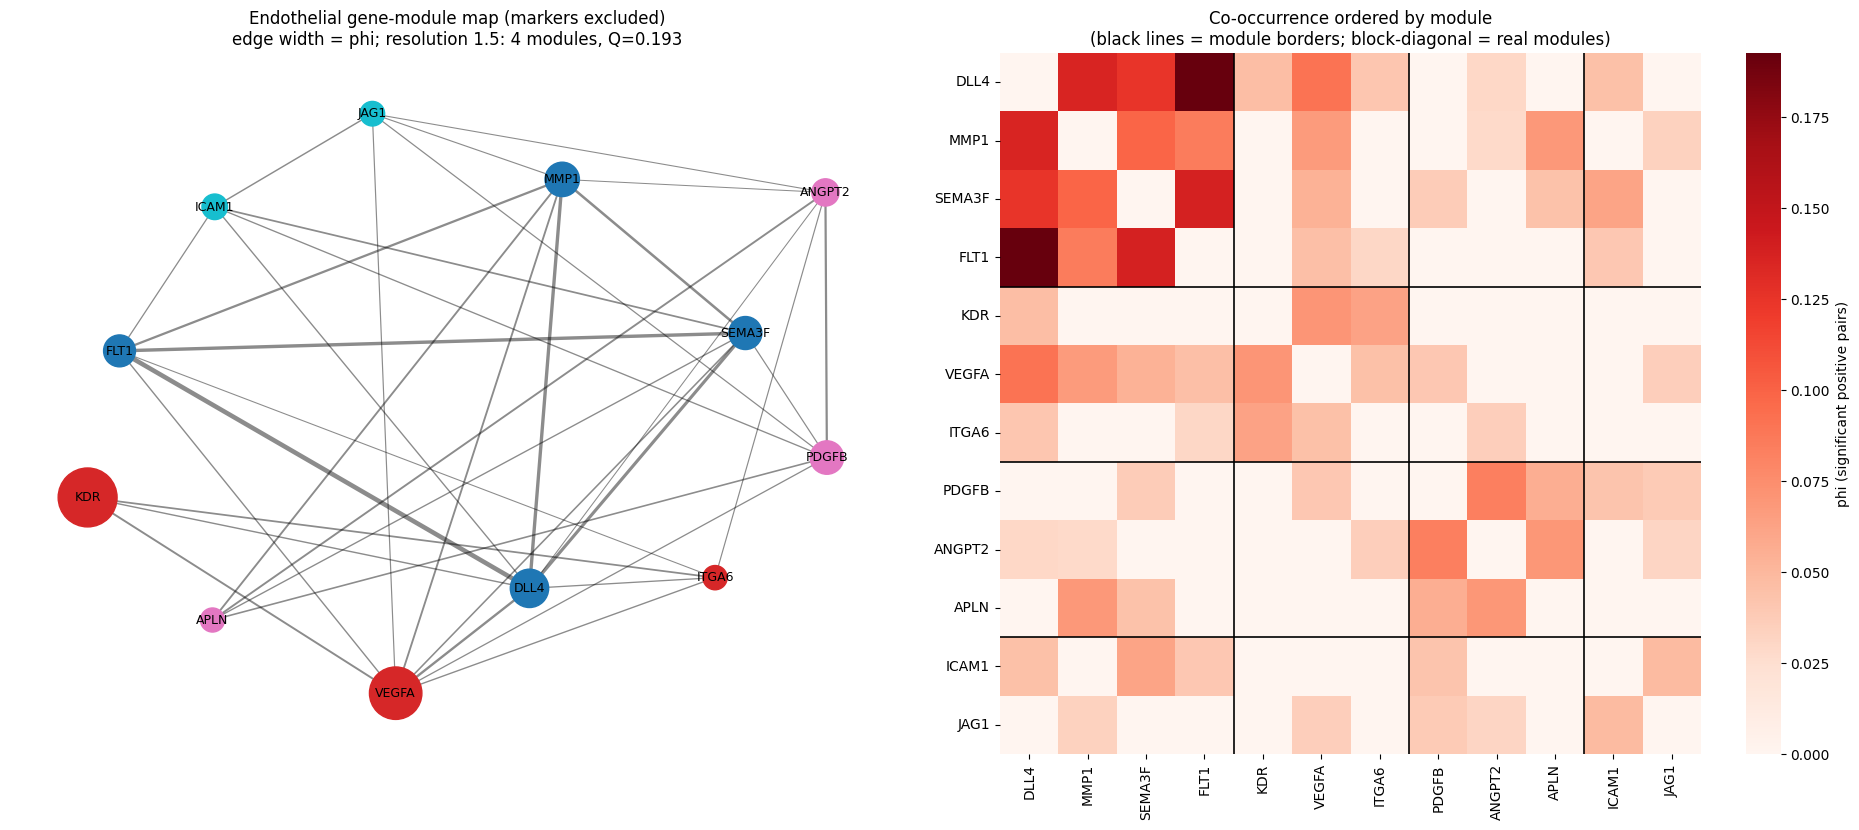

Endothelial gene modules (phi, resolution 1.5): 4 modules, Q = 0.193
  module 0 [sprouting / remodelling]: DLL4, MMP1, SEMA3F, FLT1
  module 1 [VEGF response / migration]: KDR, VEGFA, ITGA6
  module 2 [angiogenic / perivascular]: PDGFB, ANGPT2, APLN
  module 3 [activated / inflammatory-Notch]: ICAM1, JAG1


In [62]:
# RESULT: gene-module map + module-ordered co-occurrence heatmap
RESOLUTION = 1.5
Gp = nx.Graph()
Gp.add_nodes_from(module_genes)
for r in pos.itertuples():
    Gp.add_edge(r.g1, r.g2, weight=float(r.phi))

communities = list(nx.community.greedy_modularity_communities(Gp, weight="weight", resolution=RESOLUTION))
# greedy_modularity_communities(...) is a community-detection algorithm. 
# It starts with every gene in its own community, then repeatedly asks which two communities should be merged 
# to increase the overall modularity the most. It stops when no further merge improves modularity.
# Are there more/stronger connections inside these proposed modules than we would expect given how connected 
# the genes are overall?
Q = nx.community.modularity(Gp, communities, weight="weight")
module_of = {g: m for m, com in enumerate(communities) for g in com}
n_mod = len(communities)

# Biological label per module, matched by gene content (robust to community ordering).
signatures = [
    (["DLL4", "MMP1", "SEMA3F", "FLT1"], "sprouting / remodelling"),
    (["PDGFB", "ANGPT2", "APLN"], "angiogenic / perivascular"),
    (["KDR", "VEGFA", "ITGA6"], "VEGF response / migration"),
    (["ICAM1", "JAG1"], "activated / inflammatory-Notch"),
]
def module_label(com):
    genes_set = set(com)
    return max(signatures, key=lambda s: len(set(s[0]) & genes_set))[1]

# --- Left: the gene-module map (edge width = phi, node colour = module, node size = ON frequency) ---
module_cmap = plt.get_cmap("tab10", max(n_mod, 1))
connected = [g for g in Gp.nodes() if Gp.degree(g) > 0]
H = Gp.subgraph(connected)
layout = nx.spring_layout(H, weight="weight", k=1.4, seed=1)
node_size = [200 + 1600 * on_freq[module_genes.index(g)] / on_freq.max() for g in H.nodes()]
node_color = [module_cmap(module_of[g]) for g in H.nodes()]
ew = np.array([H[u][v]["weight"] for u, v in H.edges()])
edge_width = 0.3 + 3.0 * ew / ew.max()

fig, axg = plt.subplots(1, 2, figsize=(19, 8))
nx.draw_networkx_edges(H, layout, ax=axg[0], width=edge_width, alpha=0.45)
nx.draw_networkx_nodes(H, layout, ax=axg[0], node_size=node_size, node_color=node_color)
nx.draw_networkx_labels(H, layout, ax=axg[0], font_size=9)
axg[0].set_title(f"{module_lineage} gene-module map (markers excluded)\n"
                 f"edge width = phi; resolution {RESOLUTION}: {n_mod} modules, Q={Q:.3f}")
axg[0].axis("off")

# --- Right: co-occurrence matrix ORDERED BY MODULE. Real modules = block-diagonal. ---
order = [g for com in communities for g in sorted(com, key=lambda x: -on_freq[module_genes.index(x)])]
M = pd.DataFrame(0.0, index=order, columns=order)
for r in pos.itertuples():
    M.loc[r.g1, r.g2] = r.phi
    M.loc[r.g2, r.g1] = r.phi
sns.heatmap(M, cmap="Reds", square=True, ax=axg[1],
            cbar_kws={"label": "phi (significant positive pairs)"})
for bnd in np.cumsum([len(c) for c in communities])[:-1]:
    axg[1].axhline(bnd, color="k", lw=1.2); axg[1].axvline(bnd, color="k", lw=1.2)
axg[1].set_title("Co-occurrence ordered by module\n(black lines = module borders; block-diagonal = real modules)")
plt.tight_layout(); plt.show()

print(f"Endothelial gene modules (phi, resolution {RESOLUTION}): {n_mod} modules, Q = {Q:.3f}")
for m, com in enumerate(communities):
    ordered = sorted(com, key=lambda g: -on_freq[module_genes.index(g)])
    print(f"  module {m} [{module_label(com)}]: {', '.join(ordered)}")
isolated = [g for g in module_genes if Gp.degree(g) == 0]
if isolated:
    print(f"  no significant positive partner: {', '.join(isolated)}")


[weight = phi, gamma = 1.5] 4 modules, Q = 0.193
  module 0: DLL4, MMP1, SEMA3F, FLT1
  module 1: KDR, VEGFA, ITGA6
  module 2: PDGFB, ANGPT2, APLN
  module 3: ICAM1, JAG1
[weight = log2_OR, gamma = 1.5] 4 modules, Q = 0.199
  module 0: DLL4, MMP1, SEMA3F, FLT1
  module 1: KDR, VEGFA, ITGA6
  module 2: PDGFB, ANGPT2, APLN
  module 3: ICAM1, JAG1


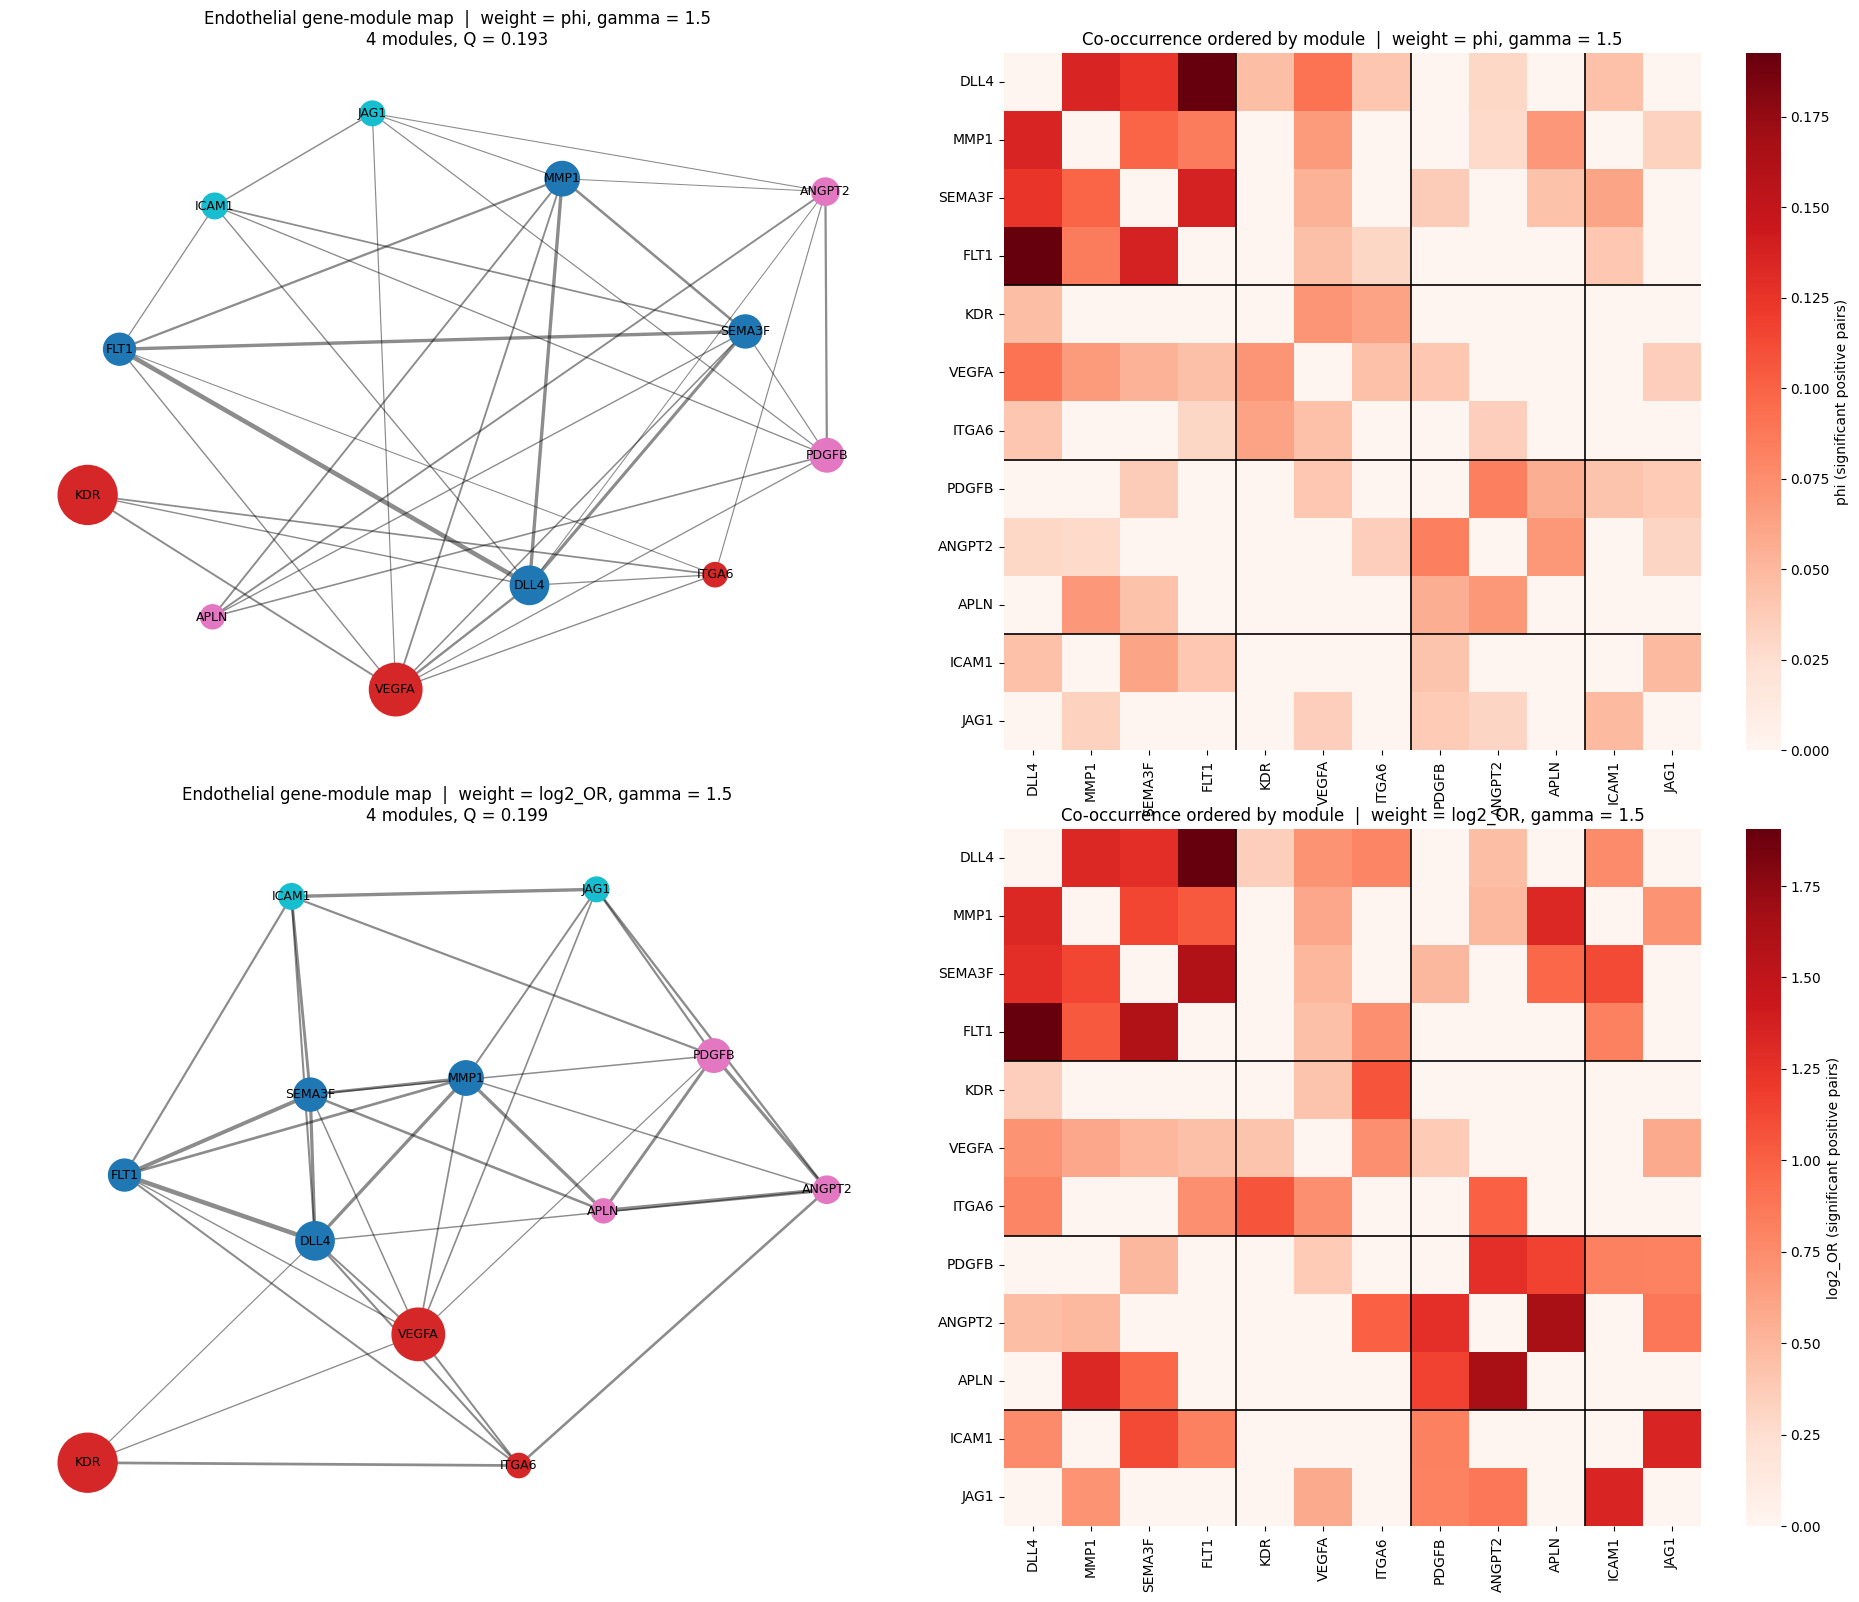

In [63]:
#  Result figure for the two best choices: (phi, gamma=1.5) and (log2 OR, gamma=1.5) 
# Same significant-positive edge set (`pos`); only the edge weight + heatmap values change.
choices = [("phi", 1.5), ("log2_OR", 1.5)]

fig, axg = plt.subplots(len(choices), 2, figsize=(19, 8 * len(choices)))
for row, (weight_col, gamma) in enumerate(choices):
    G = nx.Graph(); G.add_nodes_from(module_genes)
    for r in pos.itertuples():
        G.add_edge(r.g1, r.g2, weight=float(getattr(r, weight_col)))
    comms = list(nx.community.greedy_modularity_communities(G, weight="weight", resolution=gamma))
    Qv = nx.community.modularity(G, comms, weight="weight")
    mod_of = {gn: m for m, com in enumerate(comms) for gn in com}
    n_mod = len(comms)

    # --- Left: gene-module map (edge width = weight, node colour = module, node size = ON frequency) ---
    cmap = plt.get_cmap("tab10", max(n_mod, 1))
    connected = [gn for gn in G.nodes() if G.degree(gn) > 0]
    Hs = G.subgraph(connected)
    lay = nx.spring_layout(Hs, weight="weight", k=1.4, seed=1)
    nsize = [200 + 1600 * on_freq[module_genes.index(gn)] / on_freq.max() for gn in Hs.nodes()]
    ncol = [cmap(mod_of[gn]) for gn in Hs.nodes()]
    ewt = np.array([Hs[u][v]["weight"] for u, v in Hs.edges()])
    ewidth = 0.3 + 3.0 * ewt / ewt.max()

    ax_map, ax_hm = axg[row, 0], axg[row, 1]
    nx.draw_networkx_edges(Hs, lay, ax=ax_map, width=ewidth, alpha=0.45)
    nx.draw_networkx_nodes(Hs, lay, ax=ax_map, node_size=nsize, node_color=ncol)
    nx.draw_networkx_labels(Hs, lay, ax=ax_map, font_size=9)
    ax_map.set_title(f"{module_lineage} gene-module map  |  weight = {weight_col}, gamma = {gamma}\n"
                     f"{n_mod} modules, Q = {Qv:.3f}")
    ax_map.axis("off")

    # --- Right: co-occurrence matrix ordered by module (block-diagonal = real modules) ---
    order = [gn for com in comms for gn in sorted(com, key=lambda x: -on_freq[module_genes.index(x)])]
    Mh = pd.DataFrame(0.0, index=order, columns=order)
    for r in pos.itertuples():
        w = float(getattr(r, weight_col))
        Mh.loc[r.g1, r.g2] = w; Mh.loc[r.g2, r.g1] = w
    sns.heatmap(Mh, cmap="Reds", square=True, ax=ax_hm,
                cbar_kws={"label": f"{weight_col} (significant positive pairs)"})
    for bnd in np.cumsum([len(com) for com in comms])[:-1]:
        ax_hm.axhline(bnd, color="k", lw=1.2); ax_hm.axvline(bnd, color="k", lw=1.2)
    ax_hm.set_title(f"Co-occurrence ordered by module  |  weight = {weight_col}, gamma = {gamma}")

    print(f"[weight = {weight_col}, gamma = {gamma}] {n_mod} modules, Q = {Qv:.3f}")
    for m, com in enumerate(comms):
        print(f"  module {m}: {', '.join(sorted(com, key=lambda gn: -on_freq[module_genes.index(gn)]))}")
plt.tight_layout(); plt.show()
